In [4]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import matplotlib.colors as colors
import numpy as np

# 1. (Opcional) Monta drive si quieres que el repo se guarde ahí

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
main_path='/content/drive/MyDrive/GISD/CURSO4/TFG'

In [ ]:
%cd /content/drive/MyDrive/GISD/CURSO4/TFG/TFG---Carsharing-Estimation-Demand
!git status

In [9]:
!git add /content/drive/MyDrive/GISD/CURSO4/TFG/TFG---Carsharing-Estimation-Demand/eda_preliminar.ipynb

In [12]:
!git config --global user.email juanperpic@gmail.com

In [13]:
!git commit -m 'Exploración y creación del dataset'

fatal: cannot exec '.git/hooks/post-commit': Permission denied
[main 1561001] Exploración y creación del dataset
 1 file changed, 1 insertion(+)
 create mode 100644 eda_preliminar.ipynb


# Cruce de datos de diversas fuente (carsharing de milán, secciones e indicadores socioeconómicos)

In [ ]:

indicadores = pd.read_csv('/content/drive/MyDrive/GISD/CURSO4/TFG/dati-cpa_2011/Sezioni_di_Censimento/R03_indicatori_2011_sezioni.csv',
                          sep=';',
                          engine='python',
                          encoding='iso-8859-1')
milano_trips= pd.read_csv(f'{main_path}/cs_datasets/milano_trips.txt', sep=None, engine='python', header=0, encoding='utf-8')
milano_distritos = gpd.read_file('/content/drive/MyDrive/GISD/CURSO4/TFG/mapa_lombardia/R03_11_WGS84/R03_11_WGS84.shp')

In [ ]:
milano_distritos = milano_distritos[milano_distritos['PRO_COM'] == 15146].copy()

In [ ]:
# Normalize and parse date columns (remove timezone and parentheses)
s_s = milano_trips['s_date'].astype(str).str.replace(r' GMT[+-]\d{4} \(.+\)$', '', regex=True).str.strip()
s_e = milano_trips['e_date'].astype(str).str.replace(r' GMT[+-]\d{4} \(.+\)$', '', regex=True).str.strip()

# First try with a fixed format then fall back to generic parser for any leftovers
milano_trips['s_date'] = pd.to_datetime(s_s, format='%a %b %d %Y %H:%M:%S', errors='coerce')
milano_trips['e_date'] = pd.to_datetime(s_e, format='%a %b %d %Y %H:%M:%S', errors='coerce')

# For any rows that failed to parse, try a generic parse
mask_s = milano_trips['s_date'].isna()
mask_e = milano_trips['e_date'].isna()
if mask_s.any():
	milano_trips.loc[mask_s, 's_date'] = pd.to_datetime(s_s[mask_s], errors='coerce')
if mask_e.any():
	milano_trips.loc[mask_e, 'e_date'] = pd.to_datetime(s_e[mask_e], errors='coerce')

In [ ]:
# 1. Selección de columnas útiles y eliminación de las innecesarias ("to be ignored")
# Quitamos name, s_smartphonerequired, e_smartphonerequired y las vacías (charging)
columns_to_keep = [
    'vin', 'traveltime', 'google_time', 'google_distance',
    's_date', 's_coord', 's_fuel', 'e_date', 'e_coord', 'e_fuel'
]

milano_trips = milano_trips[columns_to_keep].copy()

def clean_distance(val):
    val = str(val).lower().replace(',', '.')
    if 'km' in val:
        return float(val.replace('km', '').strip())
    elif 'm' in val:
        return float(val.replace('m', '').strip()) / 1000.0
    return float(val)

# 2. Definir función para limpiar tiempos (ej: "29 mins" -> 29)
def clean_time(val):
    return int(str(val).split(' ')[0])

# Aplicamos las limpiezas
milano_trips['dist_km'] = milano_trips['google_distance'].apply(clean_distance)
milano_trips['duration_min'] = milano_trips['traveltime'].apply(clean_time)
milano_trips = milano_trips[milano_trips['dist_km'] > 0.1].copy()

milano_trips['s_date'] = pd.to_datetime(milano_trips['s_date'])
milano_trips['hour'] = milano_trips['s_date'].dt.hour
milano_trips['day_name'] = milano_trips['s_date'].dt.day_name()
# 4. Feature Engineering temporal para el modelo
milano_trips['hour'] = milano_trips['s_date'].dt.hour
milano_trips['day_of_week'] = milano_trips['s_date'].dt.dayofweek
milano_trips['month'] = milano_trips['s_date'].dt.month

def make_point(coord_str):
    parts = coord_str.split(',')
    return Point(float(parts[0]), float(parts[1]))

milano_trips['geometry'] = milano_trips['s_coord'].apply(make_point)
gdf_trips = gpd.GeoDataFrame(milano_trips, geometry='geometry', crs="EPSG:4326")

In [ ]:
# Forzamos a que ambos tengan exactamente el mismo sistema
gdf_trips = gdf_trips.to_crs(epsg=4326)
milano_distritos = milano_distritos.to_crs(epsg=4326)
trips_final = gpd.sjoin(gdf_trips, milano_distritos, how="left", predicate="within")

In [ ]:
df_entrenamiento = trips_final.merge(indicadores, on='SEZ2011', how='inner')

## Visualizción de los datos y corroborción

Total de viajes en el dataset: 151330


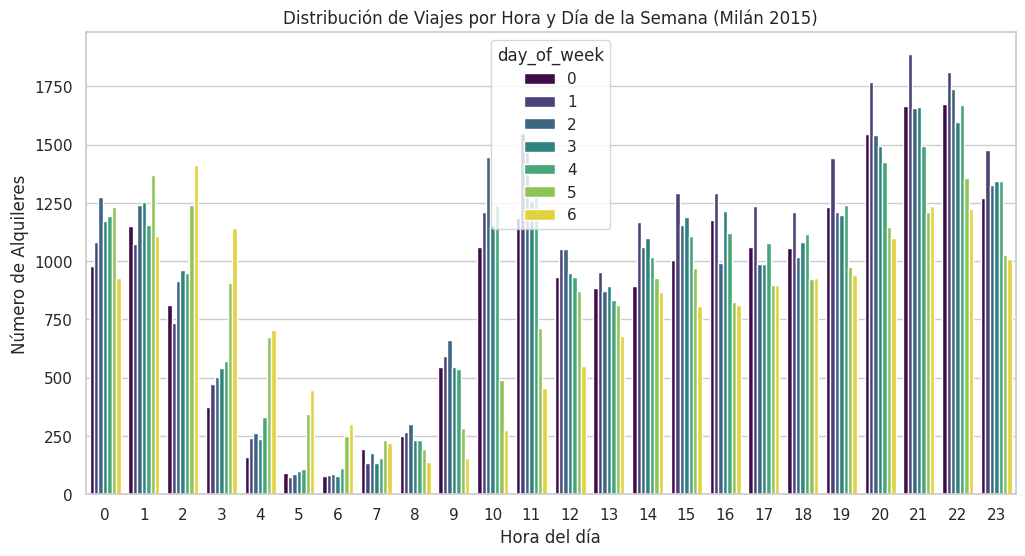

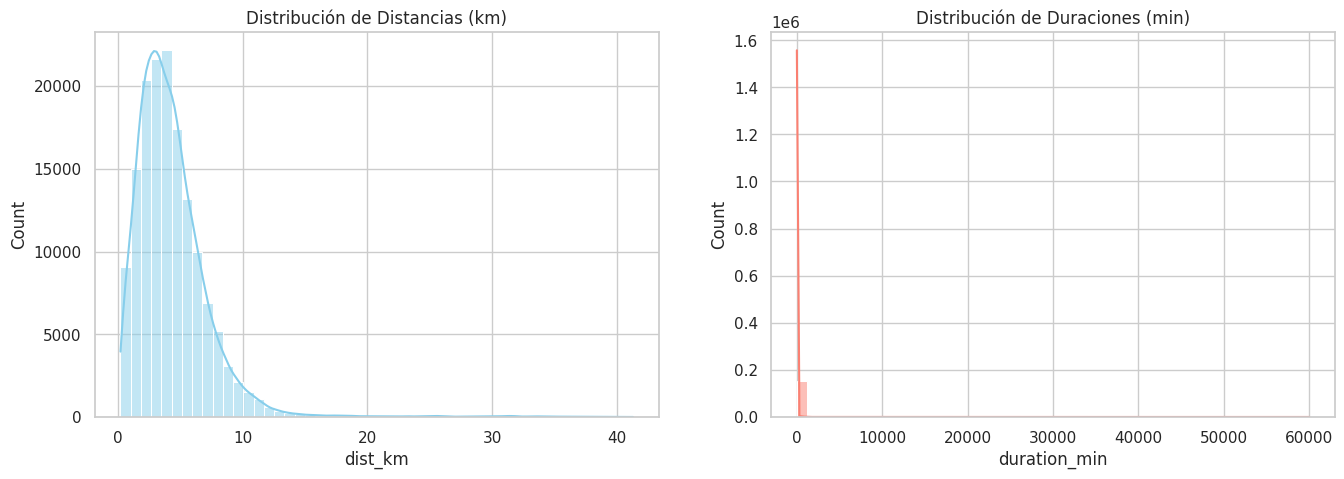

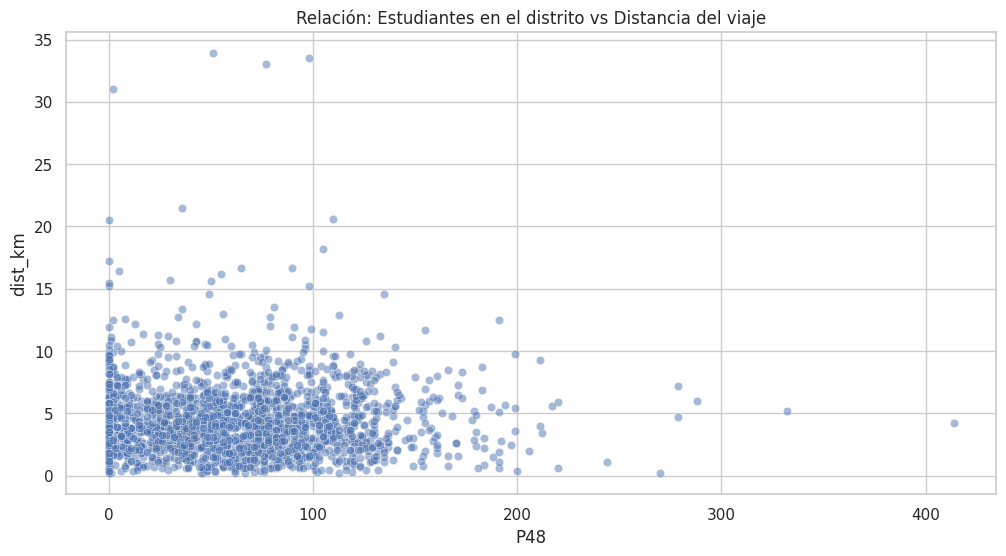


Chequeo de nulos en indicadores:
P1         0
P48        0
E3         0
SEZ2011    0
dtype: int64


In [ ]:
# Configuración estética para tu informe de TFG
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print(f"Total de viajes en el dataset: {len(df_entrenamiento)}")

# A. Distribución Temporal (¿Cuándo se usa más el servicio?)
plt.figure()
sns.countplot(data=df_entrenamiento, x='hour', hue='day_of_week', palette='viridis')
plt.title('Distribución de Viajes por Hora y Día de la Semana (Milán 2015)')
plt.xlabel('Hora del día')
plt.ylabel('Número de Alquileres')
plt.show()

# B. Análisis de Distancias y Duración
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df_entrenamiento['dist_km'], bins=50, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Distribución de Distancias (km)')
sns.histplot(df_entrenamiento['duration_min'], bins=50, kde=True, ax=ax2, color='salmon')
ax2.set_title('Distribución de Duraciones (min)')
plt.show()

# C. Relación Demanda vs Indicadores (Correlación rápida)
# Vamos a ver si los barrios con más estudiantes (P48) tienen viajes más cortos
plt.figure()
sns.scatterplot(data=df_entrenamiento.sample(2000), x='P48', y='dist_km', alpha=0.5)
plt.title('Relación: Estudiantes en el distrito vs Distancia del viaje')
plt.show()

# D. Chequeo de Calidad: Valores nulos en indicadores críticos
critical_cols = ['P1', 'P48', 'E3', 'SEZ2011']
print("\nChequeo de nulos en indicadores:")
print(df_entrenamiento[critical_cols].isnull().sum())

In [ ]:
n_secciones_con_viajes = df_entrenamiento['ACE_x'].nunique()
print(f"Tu modelo va a aprender de {n_secciones_con_viajes} áreras censales diferentes de Milán.")
# Contar cuántas secciones pertenecen al municipio de Milán
secciones_milan = milano_distritos[milano_distritos['PRO_COM'] == 15146]['ACE_x'].nunique()
print(f"Áreas censales totales en el mapa de Milán: {secciones_milan}")

# Ver cuántas de esas secciones tienen viajes en tu dataset
viajes_milan = df_entrenamiento[df_entrenamiento['PRO_COM'] == 15146]
# Calcular viajes por sección
viajes_por_sez = df_entrenamiento.groupby('ACE_x').size()

print("Estadísticas de viajes por área censal:")
print(viajes_por_sez.describe())

# Ver el Top 10 de secciones con más demanda
print("\nTop 10 áreas censales con más demanda:")
print(viajes_por_sez.sort_values(ascending=False).head(10))

Tu modelo va a aprender de 5565 micro-zonas diferentes de Milán.
Secciones totales en el mapa de Milán: 6085
Secciones de Milán con al menos un viaje: 5565
Estadísticas de viajes por sección:
count    5565.000000
mean       27.193172
std        35.467164
min         1.000000
25%         7.000000
50%        17.000000
75%        35.000000
max       778.000000
dtype: float64

Top 10 secciones con más demanda:
SEZ2011
1.514600e+11    778
1.514600e+11    541
1.514600e+11    466
1.514600e+11    395
1.514600e+11    350
1.514600e+11    342
1.514600e+11    326
1.514600e+11    323
1.514600e+11    303
1.514600e+11    302
dtype: int64


# **Construcción dataset de Machine Learning**
Agrupamiento de los registros GPS por Área censal, fecha y hora para calcular la demanda horaria en el periodo 17/05/15 al 01/07/15.

In [ ]:
df_entrenamiento['date_only'] = pd.to_datetime(df_entrenamiento['s_date']).dt.date
dataset_ml = df_entrenamiento.groupby(['ACE_x', 'date_only', 'hour']).agg({
    'vin': 'count',            # Variable objetivo: número de alquileres (Demanda)
    'P1': 'sum',             # Población total residente
    'P48': 'sum',            # Estudiantes residentes
    'P52': 'sum',            # Personas que trabajan fuera del municipio
    'E3': 'sum',             # Personas empleadas
    'Shape_Area': 'sum',     # Área del distrito para normalizar
    'day_of_week': 'first',    # Lunes=0, Domingo=6
    'month': 'first'           # Estacionalidad mensual
}).reset_index()

# Renombrar la columna del conteo a nuestra variable 'y'
dataset_ml.rename(columns={'ACE_x':'ACE','vin': 'target_demanda', 'P1':'population_resident', 'P48':'student_count','P52':'outbound_commuters','E3':'employed_resident'}, inplace=True)

# Feature Engineering extra: Densidad de demanda (fundamental para comparar distritos de distinto tamaño)
dataset_ml['demand_density'] = dataset_ml['target_demanda'] / (dataset_ml['Shape_Area'] / 1000000)
dataset_ml['pop_density'] = dataset_ml['population_resident'] / (dataset_ml['Shape_Area'] / 1000000)
# # # Visualizar el resultado
print(f"Dimensiones del dataset de entrenamiento: {dataset_ml.shape}")


Dimensiones del dataset de entrenamiento: (54985, 13)


In [ ]:
dataset_ml.sort_values(by=['date_only','hour']).head(10)

,ACE,date_only,hour,target_demanda,population_resident,student_count,outbound_commuters,employed_resident,Shape_Area,day_of_week,month,demand_density,pop_density
123,1.0,2015-05-17,2,10,1461,421,2,88,132867.850152,6,5,75.262752,10995.888007
1034,2.0,2015-05-17,2,15,1909,489,8,95,393344.347063,6,5,38.134525,4853.253935
1952,3.0,2015-05-17,2,10,2171,582,9,70,168244.749805,6,5,59.437219,12903.820194
2849,4.0,2015-05-17,2,3,593,174,2,18,57334.115649,6,5,52.324867,10342.882127
3677,5.0,2015-05-17,2,7,649,169,1,28,265429.745449,6,5,26.372327,2445.091446
4635,6.0,2015-05-17,2,5,600,204,2,28,364906.636046,6,5,13.702135,1644.256203
5524,7.0,2015-05-17,2,7,797,238,3,30,175974.423224,6,5,39.778508,4529.067267
6445,8.0,2015-05-17,2,13,2426,715,7,105,261475.955884,6,5,49.717765,9278.099746
7381,9.0,2015-05-17,2,5,1166,332,3,56,62107.662547,6,5,80.505364,18773.850958
8247,10.0,2015-05-17,2,8,1103,310,0,40,234161.212521,6,5,34.164497,4710.429999


In [ ]:
# 1. Definir el rango completo de tiempo que hay en tus datos
start_date = dataset_ml['date_only'].min()
end_date = dataset_ml['date_only'].max()
all_dates = pd.date_range(start_date, end_date).date
all_hours = np.arange(24)
all_sections = dataset_ml['ACE'].unique()

# 2. Crear un DataFrame con TODAS las combinaciones posibles (Cartesian Product)
# Esto genera el esqueleto completo: Seccion x Dia x Hora
index_grid = pd.MultiIndex.from_product(
    [all_sections, all_dates, all_hours],
    names=['ACE', 'date_only', 'hour']
).to_frame(index=False)

# 3. Cruzar el esqueleto con tus datos reales de demanda
dataset_full = pd.merge(index_grid, dataset_ml, on=['ACE', 'date_only', 'hour'], how='left')

# 4. Rellenar la demanda con 0 en los huecos (donde no hubo viajes)
dataset_full['target_demanda'] = dataset_full['target_demanda'].fillna(0)
dataset_full['demand_density'] = dataset_full['demand_density'].fillna(0)

# 5. Rellenar los datos del censo (que son constantes para cada ACE)
# Usamos groupby + ffill/bfill para que cada seccion tenga su poblacion, area, etc. siempre
census_cols = ['population_resident', 'student_count', 'outbound_commuters', 'employed_resident', 'Shape_Area', 'pop_density']
for col in census_cols:
    dataset_full[col] = dataset_full.groupby('ACE')[col].transform(lambda x: x.ffill().bfill())

# 6. Recalcular columnas temporales que se perdieron en el cruce para las filas nuevas
dataset_full['date_only'] = pd.to_datetime(dataset_full['date_only'])
dataset_full['day_of_week'] = dataset_full['date_only'].dt.dayofweek
dataset_full['month'] = dataset_full['date_only'].dt.month
dataset_full['date_only'] = dataset_full['date_only'].dt.date

# Resultado final
print(f"Dimensiones antes: {dataset_ml.shape}")
print(f"Dimensiones después (con ceros): {dataset_full.shape}")
print(f"Porcentaje de filas con demanda cero: {round((dataset_full['target_demanda'] == 0).mean() * 100, 2)}%")

Dimensiones antes: (54985, 13)
Dimensiones después (con ceros): (94944, 13)
Porcentaje de filas con demanda cero: 42.09%


In [ ]:
# 1. Preparar la geometría de las ACE (Disolver secciones en zonas)
# Usamos 'ACE_x' o 'ACE' según el nombre en tu geodataframe
milano_distritos = milano_distritos[milano_distritos['ACE']!=0]
dataset_ml = dataset_ml[dataset_ml['ACE']!=0]
ace_geoms = milano_distritos.dissolve(by='ACE').reset_index()

# 2. Calcular la demanda media por ACE desde tu dataset_ace
# (Asumiendo que ya tienes dataset_ace con la columna 'target_demanda')
avg_demand = dataset_ml.groupby('ACE')['target_demanda'].mean().reset_index()
ace_final = ace_geoms.merge(avg_demand, on='ACE', how='left').fillna(0)

# 3. Crear el mapa base centrado en Milán
m = folium.Map(location=[45.4642, 9.1900], zoom_start=12, tiles='cartodbpositron')

# 4. Generar colores aleatorios para los 86 clusters
# Usamos un mapa de colores para que se vea profesional
colormap = plt.cm.get_cmap('tab20', 86)

# 5. Añadir las zonas al mapa
folium.GeoJson(
    ace_final,
    style_function=lambda feature: {
        'fillColor': colors.to_hex(colormap(int(feature['id']) % 86)),
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.6,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['ACE', 'target_demanda'],
        aliases=['Zona ACE:', 'Demanda Media:'],
        localize=True
    )
).add_to(m)

# 6. Añadir marcadores con el número de demanda media en el centro de cada ACE
for _, row in ace_final.iterrows():
    # Obtenemos el centroide para poner el texto
    centroid = row.geometry.centroid
    folium.Marker(
        location=[centroid.y, centroid.x],
        icon=folium.DivIcon(
            html=f"""<div style="font-family: sans-serif; color: black; font-weight: bold; font-size: 10pt">
                     {row['target_demanda']:.2f}</div>"""
        )
    ).add_to(m)

m

/tmp/ipython-input-2773129237.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab20', 86)


In [113]:
df_entrenamiento

,vin,traveltime,google_time,google_distance,s_date,s_coord,s_fuel,e_date,e_coord,e_fuel,...,E23,E24,E25,E26,E27,E28,E29,E30,E31,date_only
0,WME4513341K636611,29 mins,5 mins,1.4 km,2015-05-19 11:01:43,"9.18872,45.49141,0",72,2015-05-19 11:31:26,"9.18255,45.48512,0",72,...,1,2,3,3,131,3,6,1,0,2015-05-19
1,WME4513341K636611,14 mins,12 mins,3.5 km,2015-05-17 02:00:01,"9.18195,45.46162,0",96,2015-05-17 02:14:22,"9.16616,45.48191,0",93,...,0,0,6,3,129,5,4,1,0,2015-05-17
2,WME4513341K636611,32 mins,19 mins,6.1 km,2015-05-17 02:49:20,"9.16616,45.48191,0",93,2015-05-17 03:22:08,"9.1223,45.45508,0",93,...,1,0,1,4,125,2,4,0,0,2015-05-17
3,WME4513341K636611,33 mins,12 mins,4.1 km,2015-05-18 11:46:47,"9.1223,45.45508,0",93,2015-05-18 12:20:37,"9.14877,45.47943,0",90,...,0,0,0,6,178,3,3,0,0,2015-05-18
4,WME4513341K636611,37 mins,15 mins,5.5 km,2015-05-18 20:06:31,"9.14877,45.47943,0",90,2015-05-18 20:44:24,"9.14682,45.44479,0",87,...,0,0,0,0,0,0,0,0,0,2015-05-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151325,WME4513341K828470,31 mins,5 mins,1.4 km,2015-07-01 12:55:00,"9.23662,45.47515,0",100,2015-07-01 13:26:57,"9.23682,45.47288,0",100,...,0,0,1,0,12,1,0,0,0,2015-07-01
151326,WME4513341K827801,22 mins,12 mins,3.3 km,2015-06-05 12:13:52,"9.16834,45.47064,0",51,2015-06-05 12:36:25,"9.18938,45.47544,0",51,...,0,2,2,4,142,0,8,0,0,2015-06-05
151327,WME4513341K827569,22 mins,1 min,0.3 km,2015-06-30 18:01:48,"9.18437,45.4374,0",48,2015-06-30 18:24:24,"9.18347,45.43669,0",45,...,7,2,1,3,124,2,12,0,0,2015-06-30
151328,WME4513341K827784,56 mins,16 mins,4.1 km,2015-05-23 22:05:02,"9.19184,45.47051,0",72,2015-05-23 23:01:23,"9.16935,45.45164,0",69,...,2,7,9,7,285,16,9,0,0,2015-05-23
